In [18]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import sys
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
sys.path.append("/home/grega/geoloc")
import torch
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
borders = gpd.read_file("/storage/private/MORS/gurs/borders.geojson")
borders[borders["NAZIV"] == "Slovenija"]

,NAZIV,geometry
212,Slovenija,"MULTIPOLYGON (((373891.71 48606.84, 393084.59 ..."


In [3]:
from geoloc.data.datasets.GURS import GURSDataset
from geoloc.data.datasets.GES import GESQueryImages
import torchvision.transforms.functional as TF

gdataset = GURSDataset(
    root="/storage/private/MORS/gurs",
    border="Slovenija",
    tile_size=1000
)

In [ ]:
from shapely.ops import transform
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3794", always_xy=True)

In [5]:
clean_dataset_path = "/storage/datasets/AerialLoc/Drone2Sat/GES/clean_train"

In [66]:
traj_names = ["Traj2", "Traj1_Ljubljana_150m_N-align", "TrainingImgs", "tilting", "LJ-flyby", "highalt"]
# traj_names = ["highalt"]
step_sizes = [3, 3, 3, 3, 1, 3]

running_id = 0
res = 512
for traj_name, step_size in zip(traj_names, step_sizes):
    ges_dirpath = f"/storage/datasets/AerialLoc/Drone2Sat/GES/{traj_name}"

    ges_dataset = GESQueryImages(
        root=ges_dirpath,
        transforms=None
    )

    print(f"Processing trajectory {traj_name} with {len(ges_dataset)} images.")

    for i in range(0, len(ges_dataset), step_size):

        # start_ix = 100
        # if i < start_ix:
        #     continue
        # if i > start_ix + 12:
        #     break

        dsample = ges_dataset[i]
        ges_img = dsample["image"]
        geometry = dsample["geometry"]
        # geometry = transform(transformer.transform, geometry)
        # print(dsample)
        # print(geometry)

        try:
            footprint_data = gdataset.get_data_from_footprint(geometry)
        except ValueError:
            print(f"Skipping image {i} in trajectory {traj_name} due to missing footprint data.")
            continue

        footprint_geometry = footprint_data["geometry"]

        # print(shapely.intersection(geometry, footprint_geometry).area / footprint_geometry.area)
        area_ratio = shapely.intersection(geometry, footprint_geometry).area / footprint_geometry.area
        footprint_data = footprint_data["image"]
            
        if area_ratio < 0.75 and traj_name in ["LJ-flyby"]:
            # print(footprint_data.shape)
            w, h = footprint_data.shape[-2], footprint_data.shape[-1]
            new_w, new_h = int(w * (area_ratio + 0.1)), int(h * (area_ratio + 0.1))
            footprint_data = TF.center_crop(footprint_data, (new_w, new_h))
        footprint_data = TF.resize(footprint_data, (res, res))
        ges_img = TF.resize(ges_img, (res, res))
        ges_img = ges_img.unsqueeze(0)

        # fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        # ax[0].imshow(ges_img[0].permute(1, 2, 0))
        # print(footprint_data.shape)
        # ax[1].imshow(footprint_data[0].permute(1, 2, 0))
        # plt.show()

        # fig, ax = plt.subplots(1, 6, figsize=(15, 15))
        # ax[0].imshow(ges_img[0].permute(1, 2, 0))
        # for j, im in enumerate(footprint_data):
        #     ax[j+1].imshow(im.permute(1, 2, 0))


        concat_img = torch.cat([ges_img, footprint_data], dim=0)
        save_path = os.path.join(clean_dataset_path, f"{running_id:06d}.pt")
        torch.save(concat_img, save_path)
        running_id += 1
    # break

Processing trajectory Traj2 with 401 images.
Processing trajectory Traj1_Ljubljana_150m_N-align with 451 images.
Processing trajectory TrainingImgs with 1134 images.
Skipping image 585 in trajectory TrainingImgs due to missing footprint data.
Skipping image 588 in trajectory TrainingImgs due to missing footprint data.
Skipping image 591 in trajectory TrainingImgs due to missing footprint data.
Skipping image 594 in trajectory TrainingImgs due to missing footprint data.
Skipping image 597 in trajectory TrainingImgs due to missing footprint data.
Skipping image 600 in trajectory TrainingImgs due to missing footprint data.
Skipping image 603 in trajectory TrainingImgs due to missing footprint data.
Skipping image 606 in trajectory TrainingImgs due to missing footprint data.
Skipping image 609 in trajectory TrainingImgs due to missing footprint data.
Skipping image 612 in trajectory TrainingImgs due to missing footprint data.
Skipping image 615 in trajectory TrainingImgs due to missing foo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09291691..1.0000002].


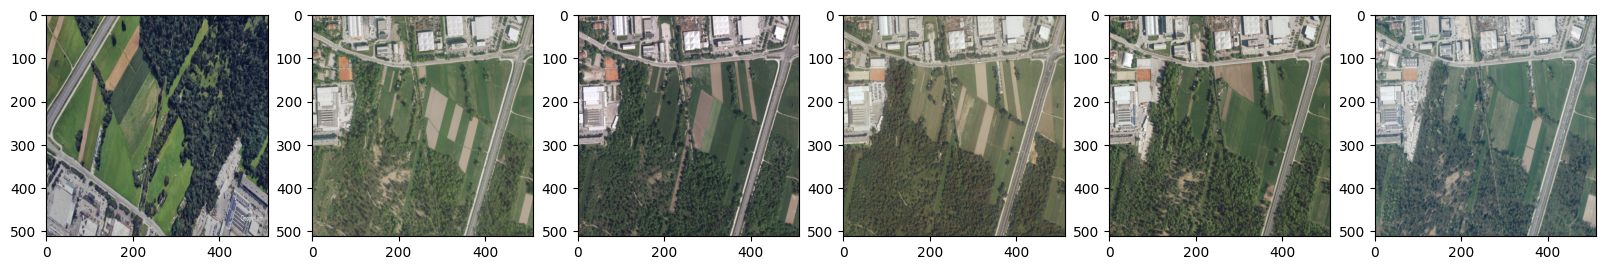

: 

In [ ]:
x = torch.load("/storage/datasets/AerialLoc/Drone2Sat/GES/clean_train/001200.pt")

fig, ax = plt.subplots(1, 6, figsize=(20, 20))
for j in range(6):
    ax[j].imshow(x[j].permute(1, 2, 0))